In [6]:
using Plots
using LinearAlgebra
using Printf

f1(x) = 5 - 24x[1] + 17x[1]^2 - (11/3)*x[1]^3 + (1/4)*x[1]^4
f2(x) = x[1]^2 * (x[1] - 2)^2 * (x[1] + 2)^2 / 8 + 0.3*x[1]

criteria = [f1, f2]
labels   = ["f1", "f2"]
colors   = [:royalblue, :crimson]

function ideal_point_search(
    criteria,
    x0::Vector{Float64},
    weights::Vector{Float64};
    T0::Float64         = 5.0,
    alpha::Float64      = 0.92,
    step::Float64       = 1.0,
    tol_T::Float64      = 1e-8,
    tol_x::Float64      = 1e-7,
    tol_f::Float64      = 1e-9,
    max_iter::Int       = 20,
    sa_steps::Int       = 60,
    no_improve_max::Int = 25
)
    x           = copy(x0)
    n           = length(x)
    T           = T0
    history     = [copy(x)]
    stop_reason = "max_iter"
    no_improve  = 0
    w           = weights ./ sum(weights)

    function find_individual_min(f, n_steps=400)
        best_v = f(x)
        for _ in 1:n_steps
            x_try = x .+ (2 .* rand(n) .- 1) .* step * 3
            v = f(x_try)
            if v < best_v; best_v = v end
        end
        return best_v
    end

    prev_dist = Inf

    for iter in 1:max_iter
        ideal_vals = [find_individual_min(f) for f in criteria]
        dist_fn(xt) = sqrt(sum(w[i] * (criteria[i](xt) - ideal_vals[i])^2 for i in eachindex(criteria)))

        cur_d  = dist_fn(x)
        best_x = copy(x)
        best_d = cur_d
        improved = false

        for _ in 1:sa_steps
            x_try = x .+ (2 .* rand(n) .- 1) .* step
            d_try = dist_fn(x_try)
            dD    = d_try - cur_d
            if dD < 0 || rand() < exp(-dD / T)
                x = x_try; cur_d = d_try
            end
            if cur_d < best_d
                best_d = cur_d; best_x = copy(x); improved = true
            end
        end

        x = best_x
        push!(history, copy(x))
        improved ? (no_improve = 0) : (no_improve += 1)
        T *= alpha

        x_prev = history[end-1]
        # if T < tol_T;                              stop_reason = "tol_T";      break end
        # if norm(x .- x_prev) < tol_x;             stop_reason = "tol_x";      break end
        # if abs(best_d - prev_dist) < tol_f && iter > 1; stop_reason = "tol_f"; break end
        # if no_improve >= no_improve_max;           stop_reason = "no_improve"; break end
        prev_dist = best_d
    end

    return x, history, stop_reason
end

ideal_point_search (generic function with 1 method)

In [7]:
function run_and_visualize(weights, gif_name, title_prefix)
    x0 = [5.0]
    x_opt, history, stop_reason = ideal_point_search(criteria, x0, weights)

    xs      = range(-5.0, 10.0, length=900)
    fvals   = [[f([xi]) for xi in xs] for f in criteria]
    ideal_v = [minimum(f([xi]) for xi in xs) for f in criteria]
    w       = weights ./ sum(weights)
    Dvals   = [sqrt(sum(w[i] * (criteria[i]([xi]) - ideal_v[i])^2 for i in eachindex(criteria))) for xi in xs]

    ylim_f = (-10.0, 20.0)

    # 1. D(x)
    D_start = sqrt(sum(w[i]*(criteria[i](history[1])-ideal_v[i])^2 for i in eachindex(criteria)))
    D_opt   = sqrt(sum(w[i]*(criteria[i](x_opt)   -ideal_v[i])^2 for i in eachindex(criteria)))
    p_d = plot(xs, Dvals; label="D(x)", color=:darkorange, lw=2,
               title=@sprintf("%s — D(x)", title_prefix),
               xlabel="x", ylabel="D", legend=:topright, size=(750, 380))
    scatter!(p_d, [history[1][1]], [D_start]; color=:gray,  ms=8, marker=:diamond, label="start")
    scatter!(p_d, [x_opt[1]],     [D_opt];   color=:black, ms=8, marker=:star5,   label="optimum")
    display(p_d)

    # 2. f1, f2
    p_f = plot(title=@sprintf("%s — f1, f2  x*=%.4f  [%s]", title_prefix, x_opt[1], stop_reason),
               xlabel="x", ylabel="f(x)", legend=:topright, size=(750, 420), ylims=ylim_f)
    for k in eachindex(criteria)
        plot!(p_f, xs, fvals[k]; label=labels[k], color=colors[k], alpha=0.5, lw=2)
    end
    for k in eachindex(criteria)
        scatter!(p_f, [history[1][1]], [criteria[k](history[1])];
                 color=:gray, ms=8, marker=:diamond, label=k==1 ? "start" : "")
    end
    for k in eachindex(criteria)
        scatter!(p_f, [x_opt[1]], [criteria[k](x_opt)];
                 color=:black, ms=8, marker=:star5, label=k==1 ? "optimum" : "")
    end
    display(p_f)

    # 3. GIF сходимости на f1, f2
    anim = @animate for (i, x_cur) in enumerate(history)
        is_last   = (i == length(history))
        title_str = is_last ?
            @sprintf("%s  iter %d  x=%.3f  [%s]", title_prefix, i-1, x_cur[1], stop_reason) :
            @sprintf("%s  iter %d  x=%.3f",        title_prefix, i-1, x_cur[1])
        p = plot(title=title_str, xlabel="x", ylabel="f(x)", legend=:topright,
                 size=(750, 420), ylims=ylim_f)
        for k in eachindex(criteria)
            plot!(p, xs, fvals[k]; label=labels[k], color=colors[k], alpha=0.5, lw=2)
        end
        for k in eachindex(criteria)
            scatter!(p, [history[1][1]], [criteria[k](history[1])];
                     color=:gray, ms=6, marker=:diamond, label=k==1 ? "start" : "")
        end
        for k in eachindex(criteria)
            scatter!(p, [x_cur[1]], [criteria[k](x_cur)]; color=colors[k], ms=7, label="")
        end
        p
    end
    display(gif(anim, gif_name, fps=2))

    # 4. Фронт Парето — только фронт и оптимум
    xs_p  = collect(range(-5.0, 10.0, length=2000))
    F     = hcat([[f([xi]) for f in criteria] for xi in xs_p]...)
    dominated = [any(j -> j != i && all(F[:,j] .<= F[:,i]) && any(F[:,j] .< F[:,i]), axes(F,2))
                 for i in axes(F,2)]
    F_par = F[:, .!dominated]
    F_opt = [f(x_opt) for f in criteria]

    p_par = plot(title=@sprintf("%s — front Pareto", title_prefix),
                 xlabel=labels[1], ylabel=labels[2], legend=:topright, size=(750, 420))
    scatter!(p_par, F_par[1,:], F_par[2,:]; color=:orange, ms=4, alpha=0.8, label="front Pareto")
    scatter!(p_par, [F_opt[1]], [F_opt[2]]; color=:black,  ms=9, marker=:star5, label="optimum")
    display(p_par)

    println(@sprintf("%-22s x*=%.5f   f1=%.4f  f2=%.4f   iter=%d   stop=%s",
            title_prefix, x_opt[1], f1(x_opt), f2(x_opt), length(history)-1, stop_reason))
end

run_and_visualize (generic function with 1 method)

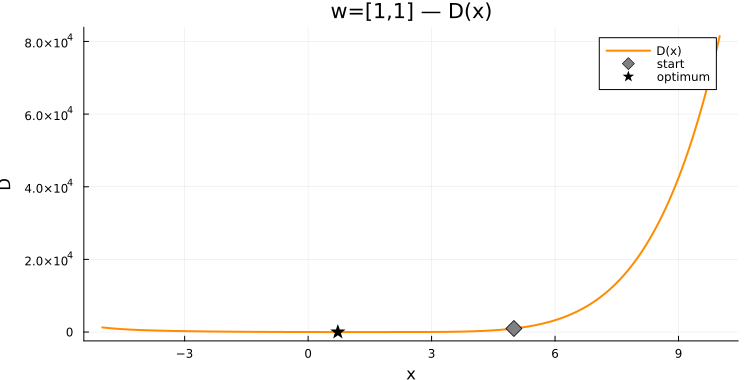

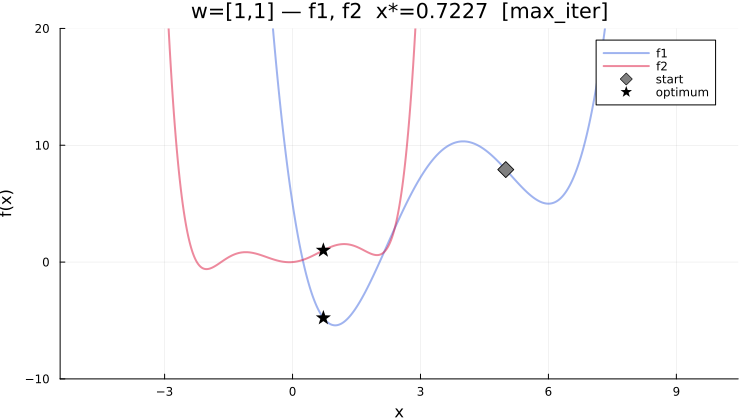

[ Info: Saved animation to /Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_equal.gif


Plots.AnimatedGif("/Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_equal.gif")
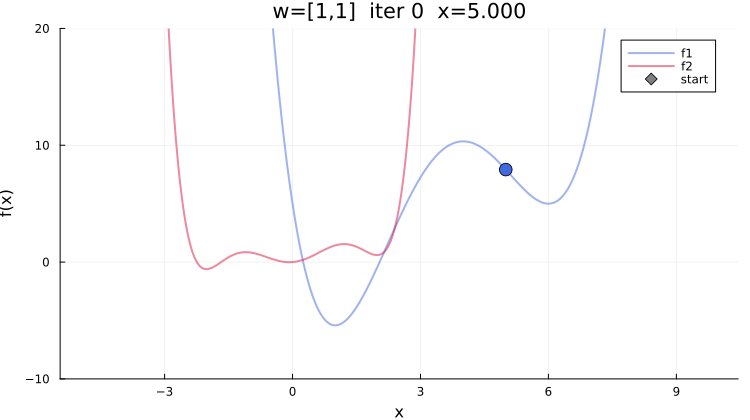

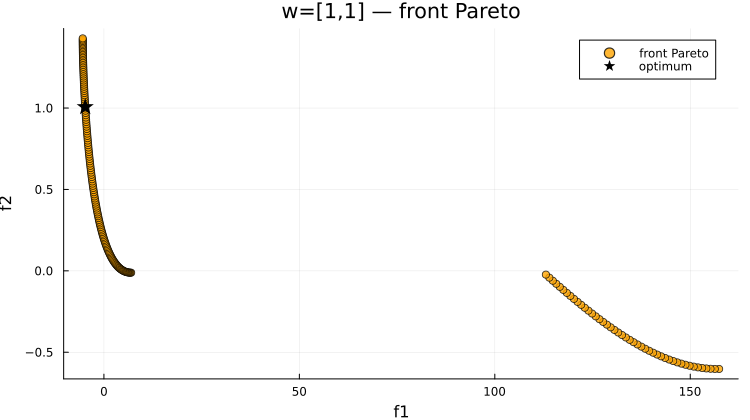

w=[1,1]                x*=0.72271   f1=-4.7817  f2=1.0064   iter=20   stop=max_iter


In [8]:
weights = [1.0, 1.0]
run_and_visualize(weights, "convergence_equal.gif", "w=[1,1]")

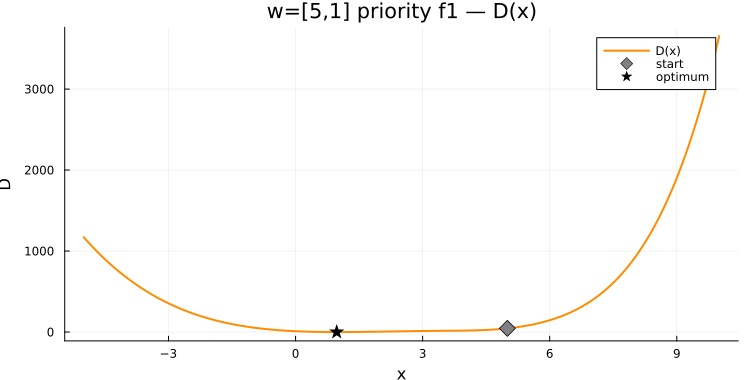

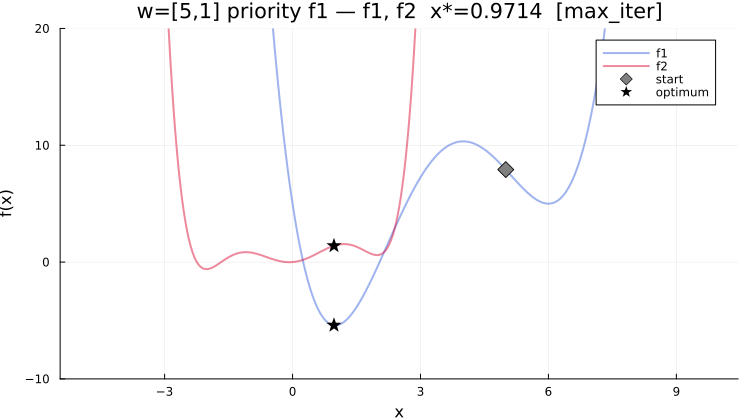

[ Info: Saved animation to /Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_f1.gif


Plots.AnimatedGif("/Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_f1.gif")
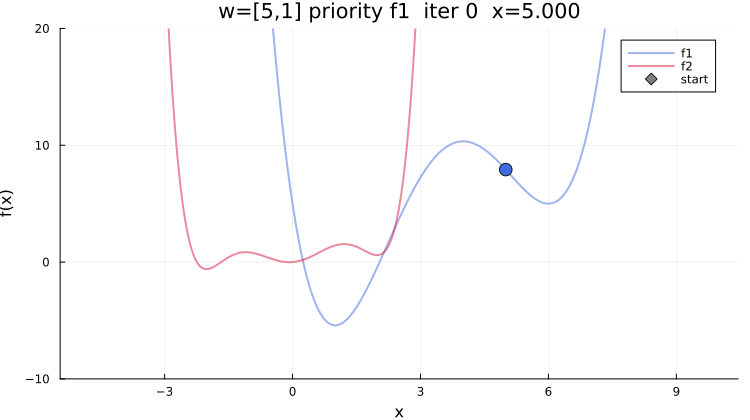

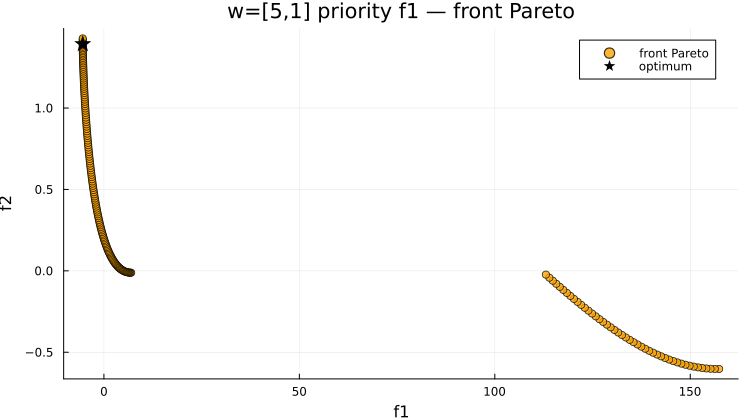

w=[5,1] priority f1    x*=0.97139   f1=-5.4105  f2=1.3933   iter=20   stop=max_iter


In [9]:
weights = [1000.0, 1.0]
run_and_visualize(weights, "convergence_f1.gif", "w=[5,1] priority f1")

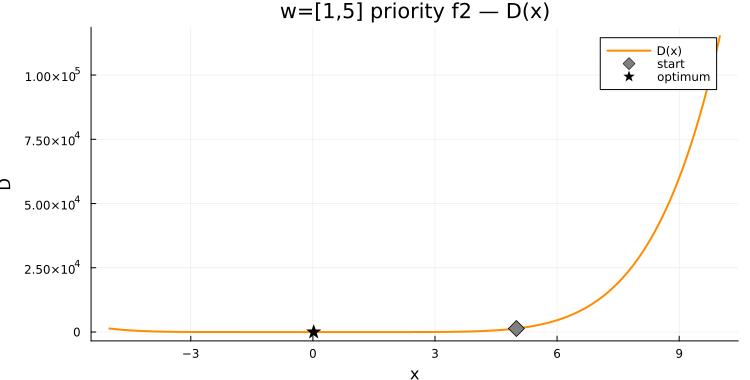

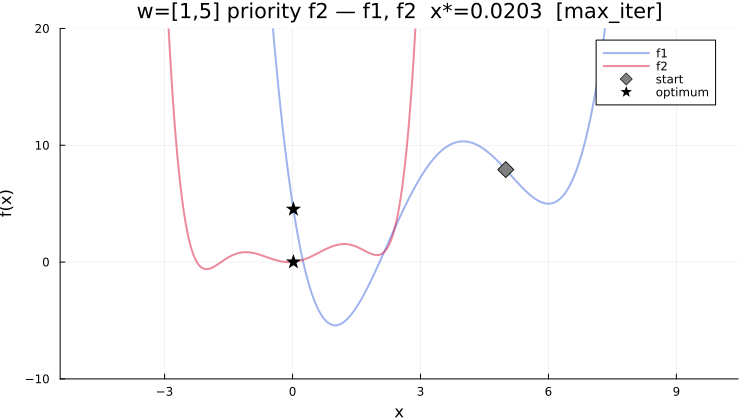

[ Info: Saved animation to /Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_f2.gif


Plots.AnimatedGif("/Users/terminal3d/Documents/files/sem8/optimization/let8/convergence_f2.gif")
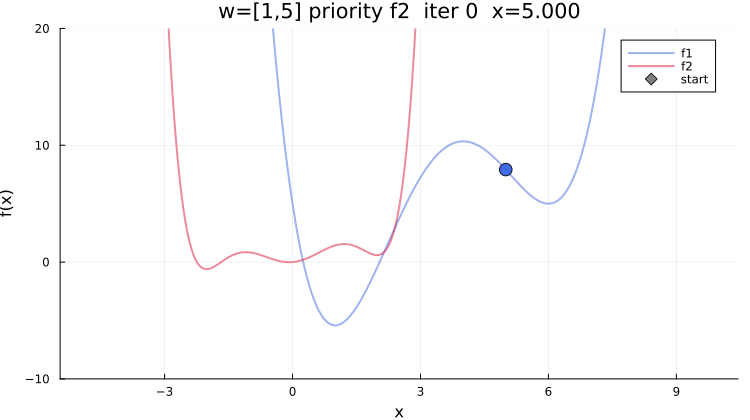

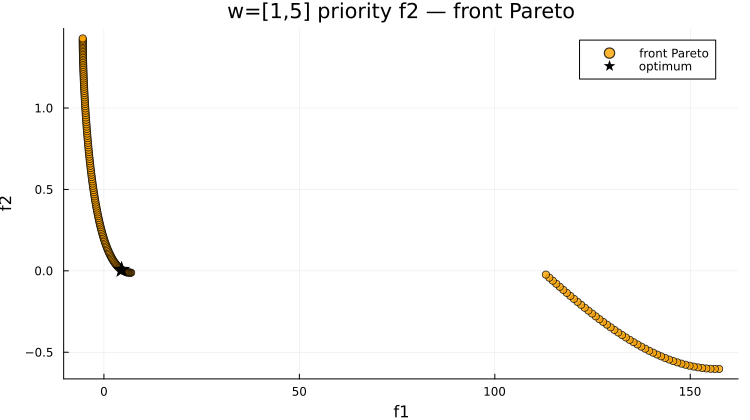

w=[1,5] priority f2    x*=0.02027   f1=4.5204  f2=0.0069   iter=20   stop=max_iter


In [10]:
weights = [1.0, 1000.0]
run_and_visualize(weights, "convergence_f2.gif", "w=[1,5] priority f2")